# 🏏 PSL ML Project
## Notebook 2: Exploratory Data Analysis (EDA)
Yahan hum data ko visualize karein ge — teams, batsmen, bowlers, runs, wickets sab kuch!

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style set karo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

df = pd.read_csv('E:/PSL_Predictor/data/raw/psl_data.csv')
print('✅ Data loaded! Shape:', df.shape)

✅ Data loaded! Shape: (73784, 27)


### 1. Runs Distribution

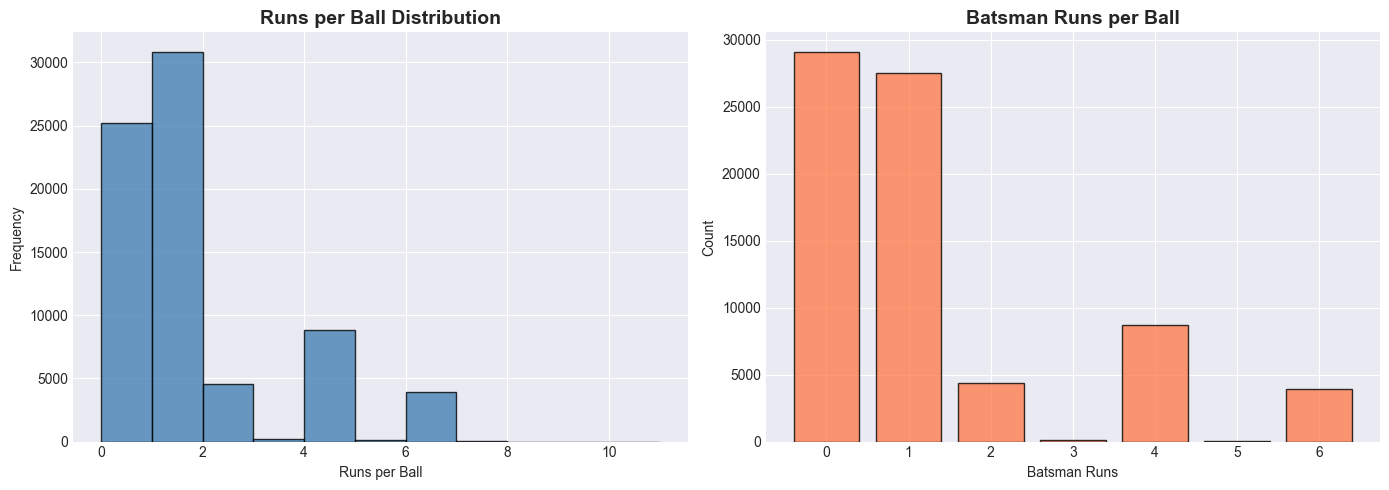

Plot saved!


In [13]:
# Total runs per over
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of runs per ball
axes[0].hist(df['total_runs'], bins=range(0, 12), edgecolor='black', color='steelblue', alpha=0.8)
axes[0].set_title('Runs per Ball Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Runs per Ball')
axes[0].set_ylabel('Frequency')

# Batsman runs per ball
run_counts = df['batsman_runs'].value_counts().sort_index()
axes[1].bar(run_counts.index, run_counts.values, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_title('Batsman Runs per Ball', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Batsman Runs')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('E:\PSL_Predictor\plots\ 01_runs_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

### 2. Team Performance Analysis

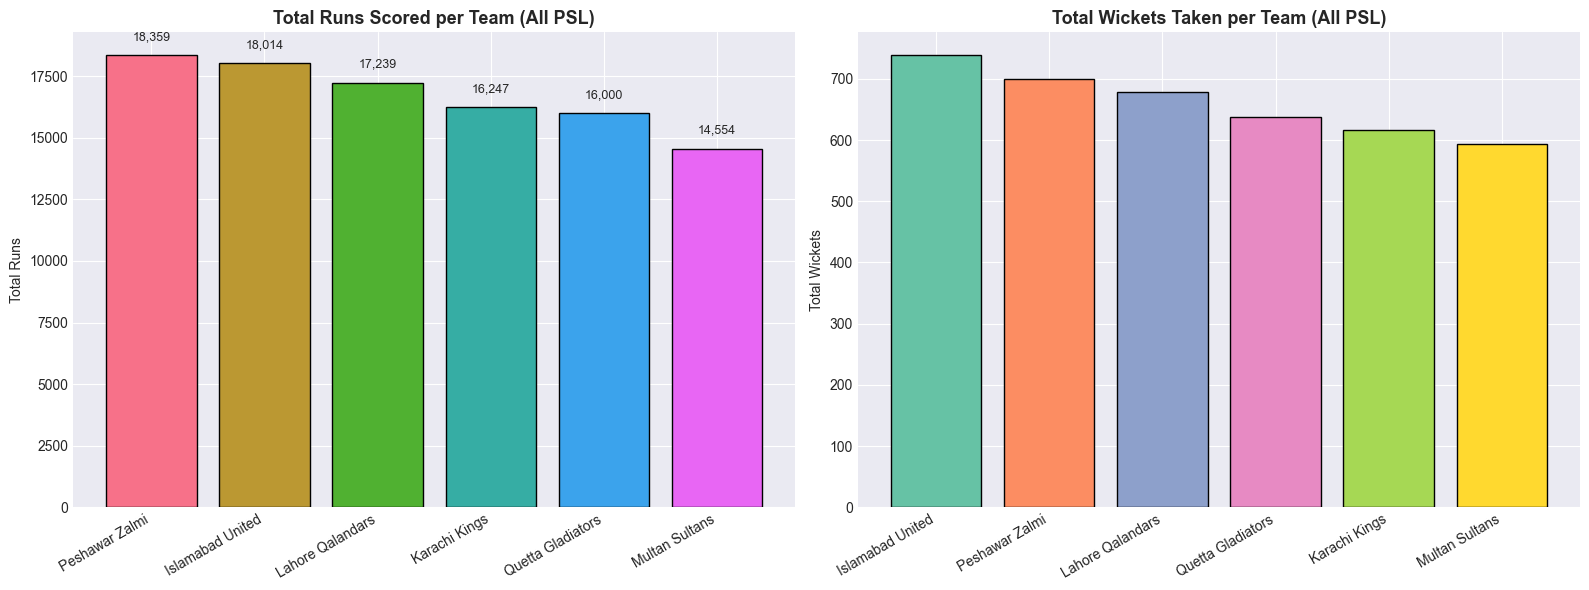

In [ ]:
# Total runs per team (batting)
team_runs = df.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total runs
bars = axes[0].bar(team_runs.index, team_runs.values, color=sns.color_palette('husl', 6), edgecolor='black')
axes[0].set_title('Total Runs Scored per Team (All PSL)', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(team_runs.index, rotation=30, ha='right')
axes[0].set_ylabel('Total Runs')
for bar, val in zip(bars, team_runs.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# Total wickets taken
team_wickets = df[df['is_wicket']==True].groupby('bowling_team').size().sort_values(ascending=False)
axes[1].bar(team_wickets.index, team_wickets.values, color=sns.color_palette('Set2', 6), edgecolor='black')
axes[1].set_title('Total Wickets Taken per Team (All PSL)', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(team_wickets.index, rotation=30, ha='right')
axes[1].set_ylabel('Total Wickets')

plt.tight_layout()
plt.savefig('E:\PSL_Predictor/plots/02_team_performance.png', dpi=150, bbox_inches='tight')
plt.show()

### 3. Top Batsmen & Bowlers

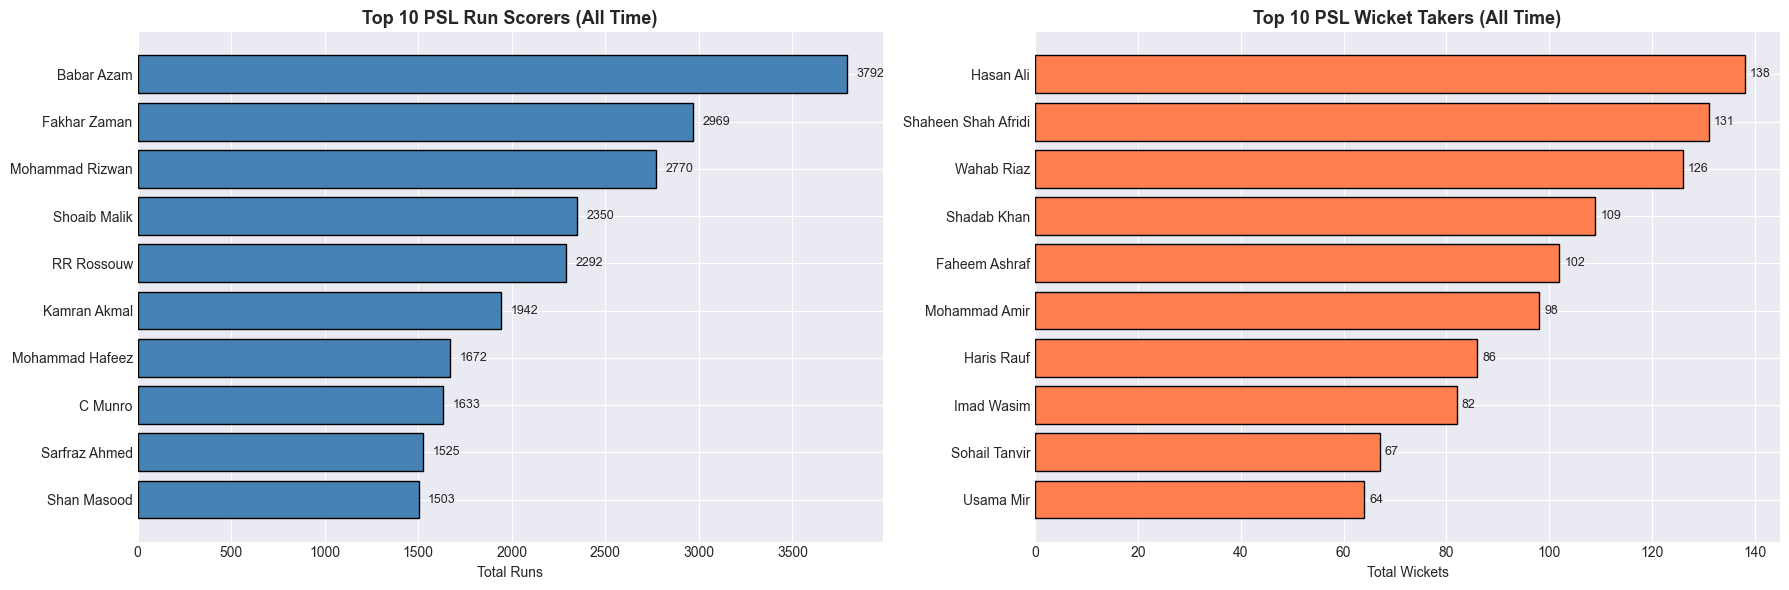

In [9]:
# Top 10 Run Scorers
top_batsmen = df.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(top_batsmen.index[::-1], top_batsmen.values[::-1], color='steelblue', edgecolor='black')
axes[0].set_title('Top 10 PSL Run Scorers (All Time)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Runs')
for i, (name, runs) in enumerate(zip(top_batsmen.index[::-1], top_batsmen.values[::-1])):
    axes[0].text(runs + 50, i, str(runs), va='center', fontsize=9)

# Top 10 Wicket Takers
top_bowlers = df[df['is_wicket']==True].groupby('bowler').size().sort_values(ascending=False).head(10)
axes[1].barh(top_bowlers.index[::-1], top_bowlers.values[::-1], color='coral', edgecolor='black')
axes[1].set_title('Top 10 PSL Wicket Takers (All Time)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Wickets')
for i, (name, wkts) in enumerate(zip(top_bowlers.index[::-1], top_bowlers.values[::-1])):
    axes[1].text(wkts + 1, i, str(wkts), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('E:\PSL_Predictor/outputs/plots/03_top_players.png', dpi=150, bbox_inches='tight')
plt.show()

### 4. Over-by-Over Run Rate

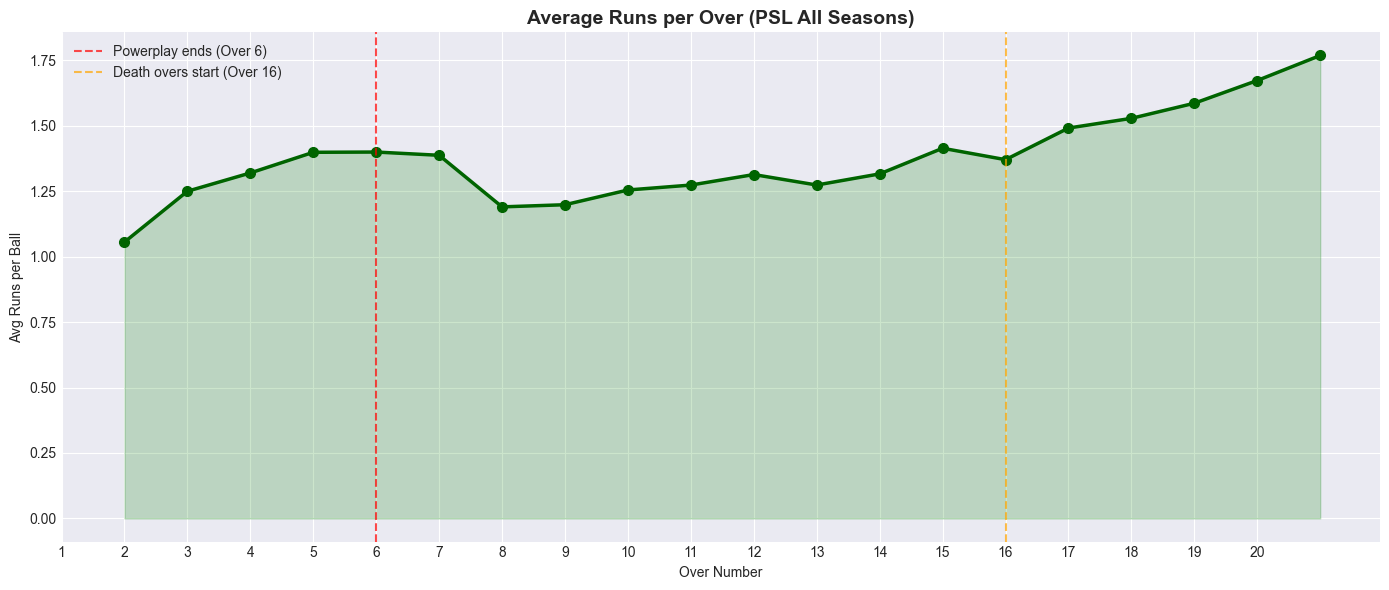

In [10]:
# Average runs per over (across all matches)
over_runs = df.groupby('over')['total_runs'].mean()

plt.figure(figsize=(14, 6))
plt.plot(over_runs.index + 1, over_runs.values, marker='o', linewidth=2.5,
         color='darkgreen', markersize=7)
plt.fill_between(over_runs.index + 1, over_runs.values, alpha=0.2, color='green')
plt.axvline(x=6, color='red', linestyle='--', alpha=0.7, label='Powerplay ends (Over 6)')
plt.axvline(x=16, color='orange', linestyle='--', alpha=0.7, label='Death overs start (Over 16)')
plt.title('Average Runs per Over (PSL All Seasons)', fontsize=14, fontweight='bold')
plt.xlabel('Over Number')
plt.ylabel('Avg Runs per Ball')
plt.legend()
plt.xticks(range(1, 21))
plt.tight_layout()
plt.savefig('E:\PSL_Predictor/outputs/plots/04_over_run_rate.png', dpi=150, bbox_inches='tight')
plt.show()

### 5. Dismissal Types

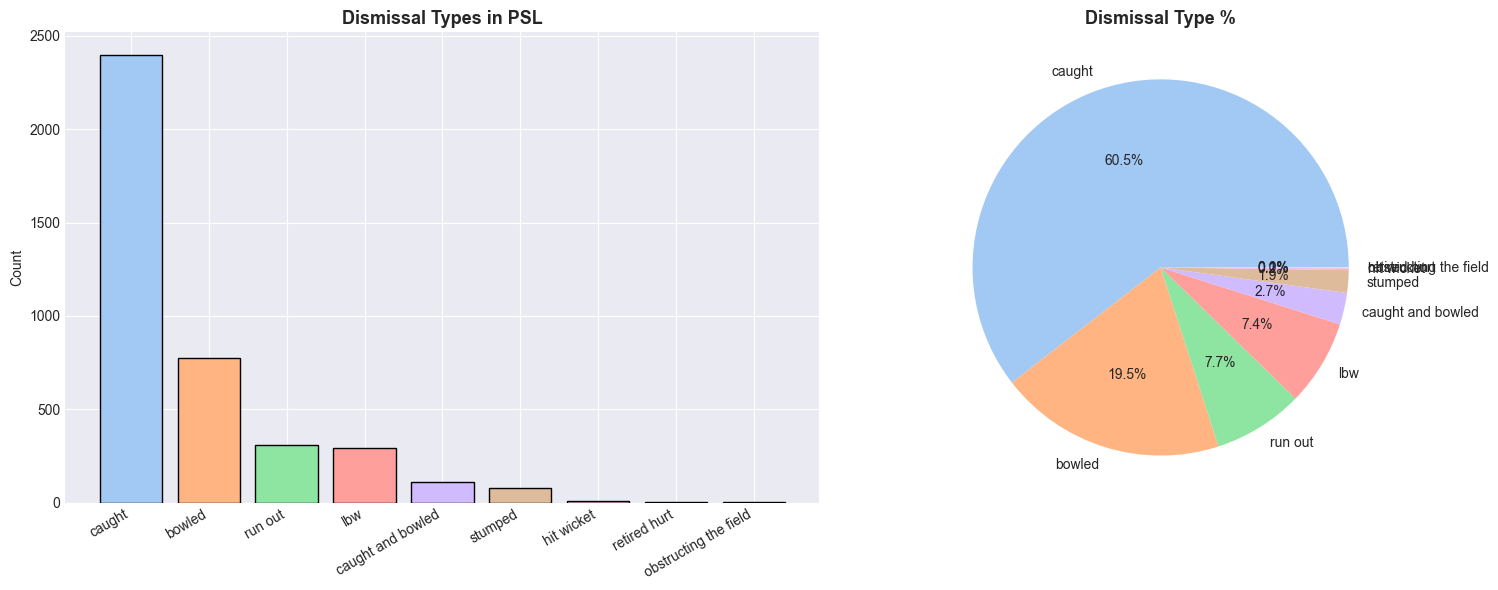

In [11]:
# Wicket kinds
dismissals = df[df['is_wicket']==True]['dismissal_kind'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
axes[0].bar(dismissals.index, dismissals.values, color=sns.color_palette('pastel'), edgecolor='black')
axes[0].set_title('Dismissal Types in PSL', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(dismissals.index, rotation=30, ha='right')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(dismissals.values, labels=dismissals.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel'))
axes[1].set_title('Dismissal Type %', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('E:\PSL_Predictor/outputs/plots/05_dismissal_types.png', dpi=150, bbox_inches='tight')
plt.show()

### 6. Season-wise Run Trends

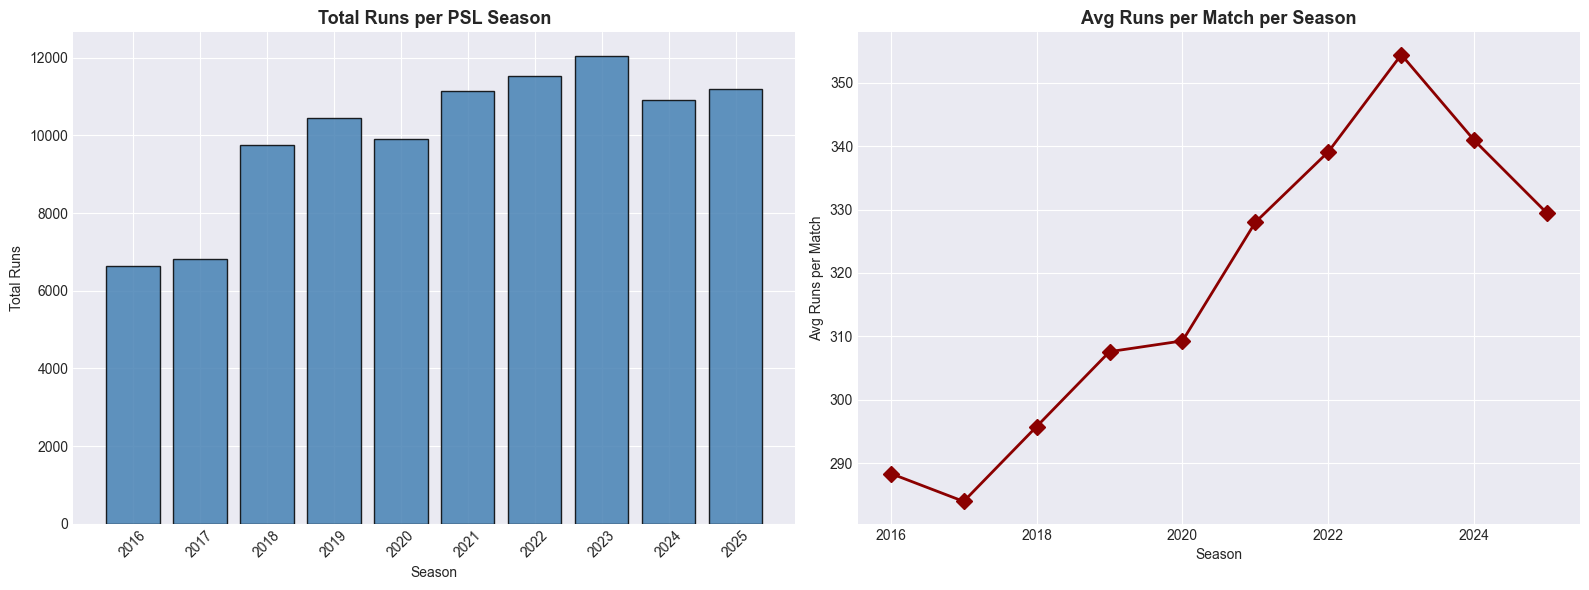

 season  total_runs  total_wickets  total_matches  runs_per_match
   2016        6634            270             23           288.4
   2017        6817            313             24           284.0
   2018        9762            419             33           295.8
   2019       10457            433             34           307.6
   2020        9899            375             32           309.3
   2021       11153            418             34           328.0
   2022       11530            428             34           339.1
   2023       12051            445             34           354.4
   2024       10909            403             32           340.9
   2025       11201            462             34           329.4


In [12]:
# Runs per season
season_stats = df.groupby('season').agg(
    total_runs=('total_runs', 'sum'),
    total_wickets=('is_wicket', 'sum'),
    total_matches=('match_id', 'nunique')
).reset_index()
season_stats['runs_per_match'] = (season_stats['total_runs'] / season_stats['total_matches']).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(season_stats['season'].astype(str), season_stats['total_runs'],
            color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_title('Total Runs per PSL Season', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Total Runs')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(season_stats['season'], season_stats['runs_per_match'],
             marker='D', linewidth=2, color='darkred', markersize=8)
axes[1].set_title('Avg Runs per Match per Season', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Avg Runs per Match')

plt.tight_layout()
plt.savefig('E:\PSL_Predictor/outputs/plots/06_season_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print(season_stats.to_string(index=False))

## ✅ EDA Complete!
- Runs, teams, players, overs sab analyze ho gaya
- Plots `../outputs/plots/` mein save ho gaye hain
- **Next:** Feature Engineering notebook mein ML ke liye data prepare karein ge